# 📊 StockHeatMap — SDD 教學示範 Notebook
### Spec-Driven Development × 滾雪球開發 × AI 協作實踐

> **課程**: AIASE 2026 — Generative AI Application Systems and Engineering  
> **作者**: Kun-Ta Chuang / NCKU CSIE  
> **版本**: v1.0 (2026-03-04)

---

## 🗺️ 學習路徑

```
Section 0 │ PRD → SDD 方法論概覽
Section 1 │ Gen-1：靜態資料 + 基礎 Treemap（可完整執行）
Section 2 │ Gen-2：即時 API + 快取 + CLI 基礎
Section 3 │ Gen-3：多地區 + 完整 CLI + 多格式輸出
Section 4 │ 測試即規格：三代累積的 Test Contract
Section 5 │ SDD × AI 協作：從規格到 Prompt 工程
```

**本 Notebook 的特色：**
- ✅ Section 0-1 完整可在 Colab 執行，看到實際熱力圖輸出
- 📖 Section 2-3 為架構教學，展示程式碼設計與模組規格
- 🧪 Section 4 為測試哲學與實作完整示範
- 🤖 Section 5 示範如何將 SDD 規格轉化為 AI Prompt


---
## Section 0：PRD → SDD 方法論概覽

### 0.1 問題陳述：為什麼需要 Spec-Driven Development？

> "Vibe Coding 能快速起步，但沒有規格的程式碼，是無法被客戶驗收、也無法被團隊維護的。"

傳統開發流程的痛點：
- PRD 描述「做什麼」，但工程師仍需自己詮釋「怎麼做」
- 驗收標準模糊，客戶與工程師各有各的期待
- 每次迭代都要重新對齊理解

**SDD 的核心主張：** 每個開發階段都對應一份**完整的、可執行驗收的規格文件（Generation）**

### 0.2 PRD 與 SDD 的銜接關係


In [1]:
# 用 ASCII Art 視覺化 SDD 的滾雪球策略
print("""
PRD（產品願景：做什麼）
  └─▶ SDD Gen-1（最小可驗證規格：靜態資料 → Treemap PNG）
        ├── Scope Declaration（做什麼、不做什麼）
        ├── Data Schema      （資料結構定義）
        ├── Module Spec      （模組職責與介面）
        ├── Test Contract    （驗收測試案例）
        └── Demo Checklist   （客戶檢核清單）
              │
              ▼ 客戶確認 ✓ → 凍結規格
        SDD Gen-2（新增：即時 API + 快取 + 基礎 CLI）
              │
              ▼ 客戶確認 ✓ → 凍結規格
        SDD Gen-3（完整：多地區 + 完整 CLI + 多格式輸出）
              │
              ▼ 正式交付 ✓
""")

print("="*60)
print("關鍵原則：每一代都是完整的可執行規格，不是草稿")
print("規格一旦通過客戶檢核即凍結，後續修改開新 Generation")



PRD（產品願景：做什麼）
  └─▶ SDD Gen-1（最小可驗證規格：靜態資料 → Treemap PNG）
        ├── Scope Declaration（做什麼、不做什麼）
        ├── Data Schema      （資料結構定義）
        ├── Module Spec      （模組職責與介面）
        ├── Test Contract    （驗收測試案例）
        └── Demo Checklist   （客戶檢核清單）
              │
              ▼ 客戶確認 ✓ → 凍結規格
        SDD Gen-2（新增：即時 API + 快取 + 基礎 CLI）
              │
              ▼ 客戶確認 ✓ → 凍結規格
        SDD Gen-3（完整：多地區 + 完整 CLI + 多格式輸出）
              │
              ▼ 正式交付 ✓

關鍵原則：每一代都是完整的可執行規格，不是草稿
規格一旦通過客戶檢核即凍結，後續修改開新 Generation


### 0.3 本專案：StockHeatMap

**PRD 核心目標（from `StockHeatMap_PRD.md`）：**

| 版本 | 目標 | 關鍵功能 |
|------|------|---------|
| CLI v1（MVP） | 跨地區股市熱力圖 CLI 工具 | 多地區資料 / Treemap / 多格式輸出 |
| Web v2 | 互動式網頁版 | D3.js Treemap / 個股鑽取 / K線圖 |

**目標使用者（from PRD）：**
- 個人投資者：每日盤後快速掌握多國市場概況  
- 量化研究員：排程產出熱力圖整合進分析 pipeline  
- 財經教育者：課堂展示市場結構與資金流動  

**本 Notebook 的 SDD 範圍：CLI MVP（Gen-1 → Gen-3）**


---
## Section 1：SDD Gen-1 — 最小可驗證原型

### Gen-1 Scope Declaration

**版本**：Gen-1 v1.0  
**目標**：證明核心 Treemap 渲染邏輯可行，用靜態資料產出一張美股熱力圖。

| ✅ 本版本做的事 | ❌ 本版本不做的事 |
|--------------|----------------|
| 從本地 JSON 載入美股樣本資料 | 不呼叫任何外部 API |
| Treemap 渲染（面積=市值，顏色=漲跌幅） | 不支援 CLI 參數 |
| 輸出 PNG 圖檔 | 不支援多地區 |
| - | 不處理 Sector 分群 |

> 💡 **為什麼這樣切？** 客戶最想先看到「視覺效果對不對」。先用靜態資料排除所有 API、CLI 的複雜度，一週內就能讓客戶看到實物並給回饋。


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 環境安裝（Colab 首次執行）
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('squarify')
print("✅ squarify 安裝完成")
print("✅ matplotlib 已內建於 Colab")


✅ squarify 安裝完成
✅ matplotlib 已內建於 Colab


### 1.1 Data Schema — Gen-1 最小資料模型

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-1] models.py
# 規格來源：SDD Gen-1 § 1.2 Data Schema
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from dataclasses import dataclass, asdict

@dataclass
class StockEntry:
    """
    單一股票的資料結構 — Gen-1 最小欄位集

    設計原則：
    - 欄位只包含 Treemap 渲染需要的最小集合
    - 從 Gen-1 就確定好欄位名稱，Gen-2/3 向後相容擴展
    - 使用 dataclass 確保型別清晰，易於 JSON 序列化
    """
    symbol:     str    # 股票代號，如 "NVDA"
    name:       str    # 公司名稱，如 "NVIDIA Corporation"
    market_cap: float  # 市值（USD），用於決定方塊面積
    change_pct: float  # 當日漲跌幅（%），如 -5.18 代表跌 5.18%
    sector:     str    # 產業板塊，如 "Electronic Technology"

# 測試 Schema
sample = StockEntry("NVDA", "NVIDIA Corp", 2.8e12, -5.18, "Electronic Technology")
print(f"StockEntry 範例：{sample}")
print(f"Dict 格式：{asdict(sample)}")


StockEntry 範例：StockEntry(symbol='NVDA', name='NVIDIA Corp', market_cap=2800000000000.0, change_pct=-5.18, sector='Electronic Technology')
Dict 格式：{'symbol': 'NVDA', 'name': 'NVIDIA Corp', 'market_cap': 2800000000000.0, 'change_pct': -5.18, 'sector': 'Electronic Technology'}


### 1.2 樣本資料 — `sample_us.json`

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 樣本資料（模擬 sample_us.json）
# 規格來源：SDD Gen-1 § 1.2 Data Schema
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import json

SAMPLE_US_DATA = [
    {"symbol": "MSFT",  "name": "Microsoft Corp",    "market_cap": 3.10e12, "change_pct":  0.48, "sector": "Technology Services"},
    {"symbol": "AAPL",  "name": "Apple Inc",          "market_cap": 2.90e12, "change_pct": -0.36, "sector": "Electronic Technology"},
    {"symbol": "NVDA",  "name": "NVIDIA Corp",        "market_cap": 2.80e12, "change_pct": -5.18, "sector": "Electronic Technology"},
    {"symbol": "GOOGL", "name": "Alphabet Inc",       "market_cap": 2.10e12, "change_pct": -1.51, "sector": "Technology Services"},
    {"symbol": "AMZN",  "name": "Amazon.com",         "market_cap": 2.00e12, "change_pct": -1.14, "sector": "Retail Trade"},
    {"symbol": "META",  "name": "Meta Platforms",     "market_cap": 1.50e12, "change_pct":  0.63, "sector": "Technology Services"},
    {"symbol": "TSLA",  "name": "Tesla Inc",          "market_cap": 0.80e12, "change_pct": -2.13, "sector": "Consumer Durables"},
    {"symbol": "AVGO",  "name": "Broadcom Inc",       "market_cap": 0.75e12, "change_pct": -4.57, "sector": "Electronic Technology"},
    {"symbol": "NFLX",  "name": "Netflix Inc",        "market_cap": 0.38e12, "change_pct":  3.05, "sector": "Technology Services"},
    {"symbol": "CRM",   "name": "Salesforce Inc",     "market_cap": 0.28e12, "change_pct":  4.67, "sector": "Technology Services"},
    {"symbol": "AMD",   "name": "AMD Inc",            "market_cap": 0.25e12, "change_pct": -3.32, "sector": "Electronic Technology"},
    {"symbol": "SNDK",  "name": "Sandisk Corp",       "market_cap": 0.02e12, "change_pct":  3.48, "sector": "Electronic Technology"},
]

# 寫入本地檔案（模擬 JSON 資料來源）
with open("sample_us.json", "w") as f:
    json.dump(SAMPLE_US_DATA, f, ensure_ascii=False, indent=2)

print(f"✅ sample_us.json 建立完成，共 {len(SAMPLE_US_DATA)} 筆")
print(f"\n漲幅前三名：")
top3 = sorted(SAMPLE_US_DATA, key=lambda x: x['change_pct'], reverse=True)[:3]
for s in top3:
    print(f"  {s['symbol']:6s} {s['change_pct']:+.2f}%")
print(f"\n跌幅前三名：")
bot3 = sorted(SAMPLE_US_DATA, key=lambda x: x['change_pct'])[:3]
for s in bot3:
    print(f"  {s['symbol']:6s} {s['change_pct']:+.2f}%")


✅ sample_us.json 建立完成，共 12 筆

漲幅前三名：
  CRM    +4.67%
  SNDK   +3.48%
  NFLX   +3.05%

跌幅前三名：
  NVDA   -5.18%
  AVGO   -4.57%
  AMD    -3.32%


### 1.3 Module: `data_loader.py`

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-1] data_loader.py
# 規格來源：SDD Gen-1 § 1.3 Module Spec
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def load_from_json(filepath: str) -> list:
    """
    職責：從本地 JSON 檔案載入股票資料並轉為 StockEntry 列表。

    公開介面：
        load_from_json(filepath: str) -> list[StockEntry]

    約束（Test Contract 的文字版）：
        - 若檔案不存在，拋出 FileNotFoundError
        - 若 JSON 格式錯誤，拋出 json.JSONDecodeError
        - 回傳列表長度必須 > 0，否則拋出 ValueError("Empty dataset")
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        raw = json.load(f)

    if not raw:
        raise ValueError("Empty dataset")

    return [
        StockEntry(
            symbol=item['symbol'],
            name=item['name'],
            market_cap=item['market_cap'],
            change_pct=item['change_pct'],
            sector=item['sector']
        )
        for item in raw
    ]

# 測試載入
stocks = load_from_json("sample_us.json")
print(f"✅ 載入成功：{len(stocks)} 筆股票")
print(f"\n前三筆資料（依市值排序）：")
for s in stocks[:3]:
    cap_t = s.market_cap / 1e12
    print(f"  {s.symbol:6s} | 市值 ${cap_t:.2f}T | 漲跌 {s.change_pct:+.2f}% | 板塊: {s.sector}")


✅ 載入成功：12 筆股票

前三筆資料（依市值排序）：
  MSFT   | 市值 $3.10T | 漲跌 +0.48% | 板塊: Technology Services
  AAPL   | 市值 $2.90T | 漲跌 -0.36% | 板塊: Electronic Technology
  NVDA   | 市值 $2.80T | 漲跌 -5.18% | 板塊: Electronic Technology


### 1.4 Module: `treemap_renderer.py`

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-1] treemap_renderer.py — 核心渲染模組
# 規格來源：SDD Gen-1 § 1.3 Module Spec
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import squarify
import os

# ── 色階定義（規格：深紅→淺紅→灰→淺綠→深綠）─────────────────────────
CMAP_COLORS    = ['#8B0000', '#D32F2F', '#808080', '#4CAF50', '#1B5E20']
CMAP_POSITIONS = [0.0,        0.25,      0.5,       0.75,      1.0     ]
HEATMAP_CMAP   = mcolors.LinearSegmentedColormap.from_list(
    'stock_heatmap', list(zip(CMAP_POSITIONS, CMAP_COLORS))
)
VMIN, VMAX = -5.0, 5.0  # 色階邊界（%）


def _pct_to_color(change_pct: float) -> str:
    """將漲跌幅映射到色階上的顏色值（含 clamp 到 ±5%）。"""
    norm  = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
    clamped = max(min(change_pct, VMAX), VMIN)
    rgba  = HEATMAP_CMAP(norm(clamped))
    return mcolors.to_hex(rgba)


def render_heatmap(stocks: list, title: str = "Stock Heatmap — US Market",
                   figsize: tuple = (19.2, 10.8)) -> plt.Figure:
    """
    核心渲染函式：接收 StockEntry 列表，產出 Treemap Figure。

    規格約束：
    - 面積依 market_cap 相對比例（squarify 自動計算）
    - 色階：change_pct 映射到紅(-5%)→灰(0%)→綠(+5%) 連續色階
    - 每個方塊標籤顯示 symbol 與 change_pct
    - 背景色：#1a1a2e（深色主題）
    """
    sizes  = [s.market_cap for s in stocks]
    labels = [f"{s.symbol}\n{s.change_pct:+.2f}%" for s in stocks]
    colors = [_pct_to_color(s.change_pct) for s in stocks]

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.patch.set_facecolor('#1a1a2e')
    ax.set_facecolor('#1a1a2e')

    squarify.plot(
        sizes=sizes,
        label=labels,
        color=colors,
        alpha=0.92,
        ax=ax,
        text_kwargs={
            'fontsize': max(8, min(14, 120 // len(stocks))),
            'color': 'white',
            'weight': 'bold',
        }
    )

    ax.set_title(title, fontsize=18, weight='bold', pad=15, color='white')
    ax.axis('off')
    fig.tight_layout(pad=0.5)
    return fig


def save_heatmap(fig: plt.Figure, output_path: str) -> None:
    """將 Figure 儲存為圖檔，自動判斷格式（png/svg/pdf）。"""
    os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
    fig.savefig(output_path, dpi=100, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)


print("✅ treemap_renderer 模組定義完成")
print(f"\n色彩測試：")
test_values = [-6.0, -5.0, -2.5, 0.0, 2.5, 5.0, 6.0]
for v in test_values:
    color = _pct_to_color(v)
    r, g, b = int(color[1:3],16), int(color[3:5],16), int(color[5:7],16)
    tag = "🔴 紅" if r > g + 30 else ("🟢 綠" if g > r + 30 else "⚪ 灰")
    print(f"  {v:+5.1f}% → {color}  {tag}")


✅ treemap_renderer 模組定義完成

色彩測試：
   -6.0% → #8b0000  🔴 紅
   -5.0% → #8b0000  🔴 紅
   -2.5% → #d32f2f  🔴 紅
   +0.0% → #808080  ⚪ 灰
   +2.5% → #4bae4f  🟢 綠
   +5.0% → #1b5e20  🟢 綠
   +6.0% → #1b5e20  🟢 綠


### 1.5 Gen-1 主程式 `main.py` — 硬編碼版

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-1] main.py — 無 CLI 參數，硬編碼路徑
# 規格來源：SDD Gen-1 § 1.3 Module Spec
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def main_gen1():
    """Gen-1 入口點 — 硬編碼設計是刻意的：讓最核心的邏輯先跑通。"""
    # Step 1: 載入資料
    stocks = load_from_json("sample_us.json")
    print(f"[1/3] 載入 {len(stocks)} 筆股票資料")

    # Step 2: 渲染
    fig = render_heatmap(stocks)
    print("[2/3] Treemap 渲染完成")

    # Step 3: 儲存
    os.makedirs("output", exist_ok=True)
    output_path = "output/heatmap_US_gen1.png"
    save_heatmap(fig, output_path)
    print(f"[3/3] ✓ Heatmap saved to {output_path}")
    return output_path

output_path = main_gen1()


[1/3] 載入 12 筆股票資料
[2/3] Treemap 渲染完成
[3/3] ✓ Heatmap saved to output/heatmap_US_gen1.png


### 1.6 🖼️ 執行結果 — Gen-1 熱力圖

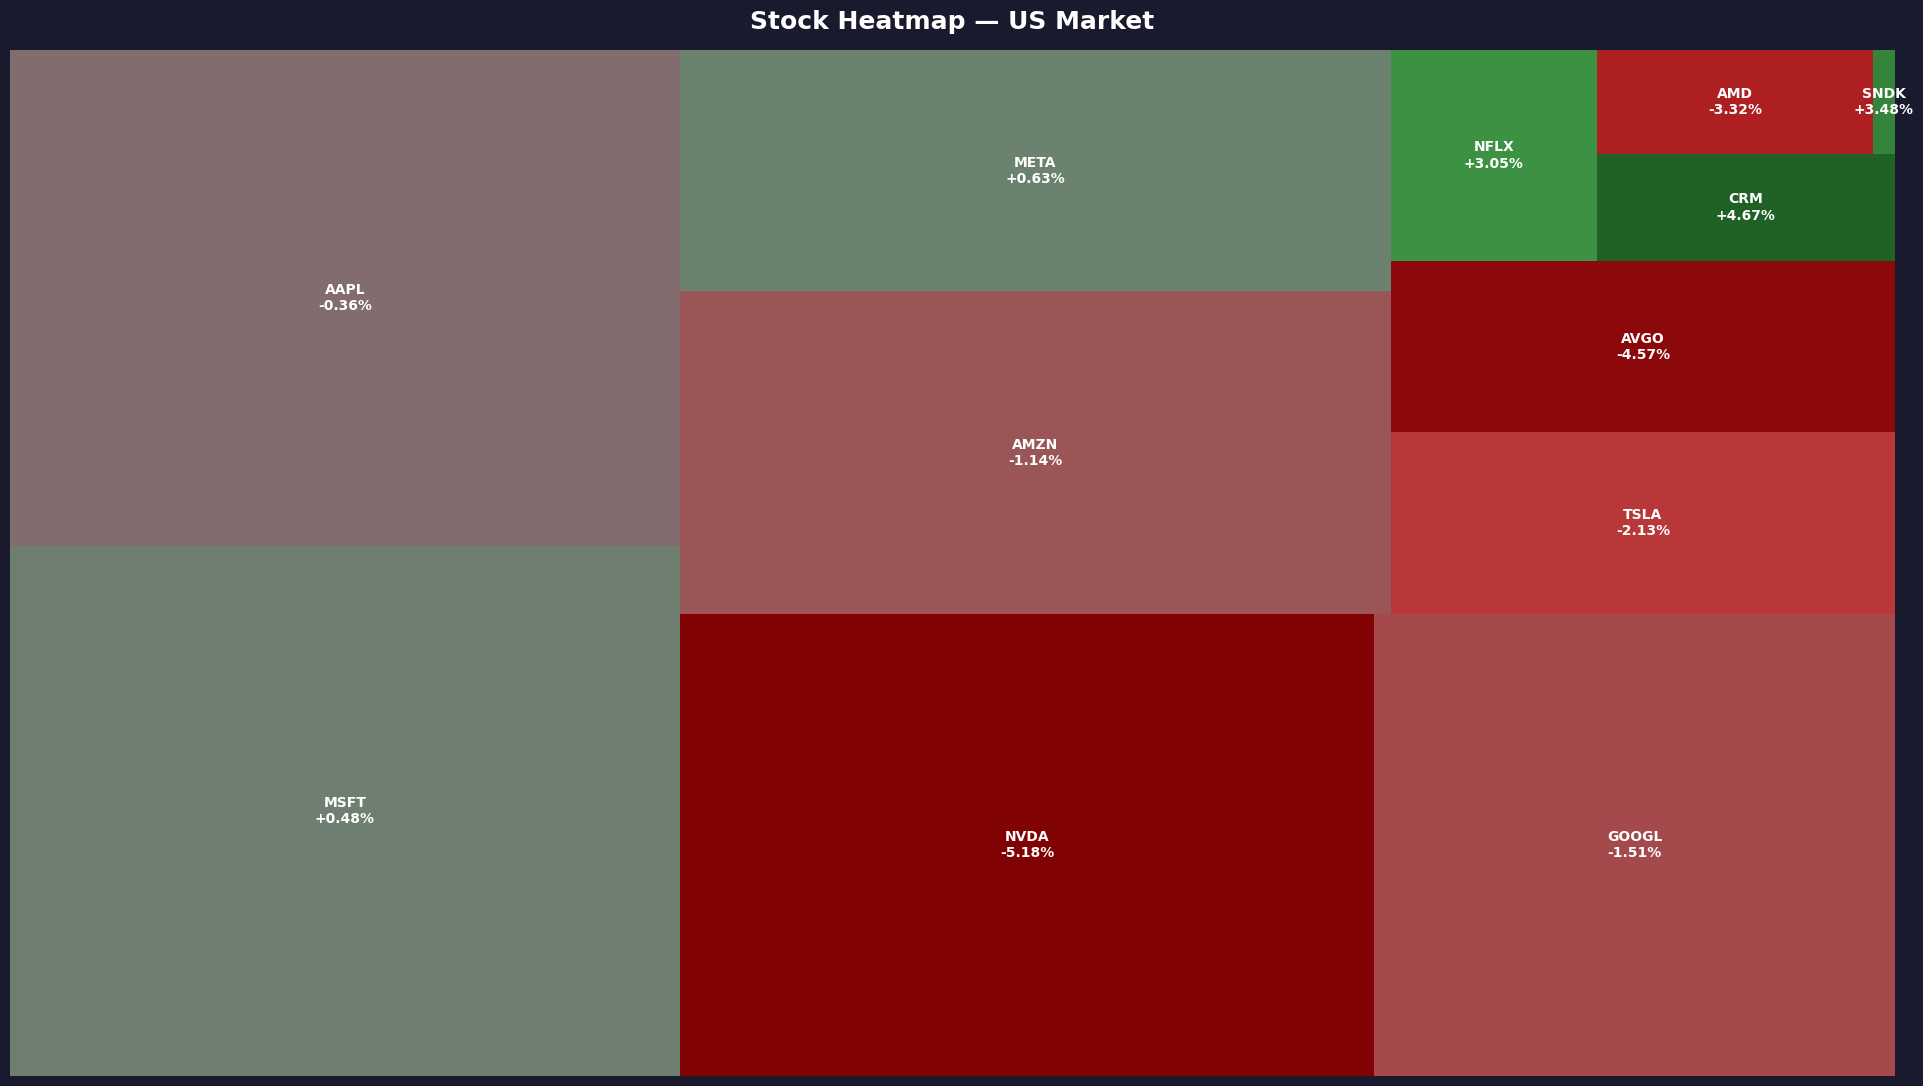


▲ Gen-1 輸出：12 檔美股的 Treemap 熱力圖
   - 面積 ∝ 市值（MSFT/AAPL/NVDA 佔最大面積）
   - 顏色 = 漲跌幅（深紅=大跌, 深綠=大漲）


In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Colab 顯示圖片
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from IPython.display import Image, display

display(Image(filename=output_path, width=900))
print("\n▲ Gen-1 輸出：12 檔美股的 Treemap 熱力圖")
print("   - 面積 ∝ 市值（MSFT/AAPL/NVDA 佔最大面積）")
print("   - 顏色 = 漲跌幅（深紅=大跌, 深綠=大漲）")


### 1.7 Gen-1 Test Contract — 驗收測試

> 測試不是「寫完功能後補的」，而是**規格的可執行版本**。  
> 每一條測試都直接對應 Scope Declaration 或 Module Spec 的一個約束。


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-1] Test Contract 執行（內嵌版，無需 pytest）
# 規格來源：SDD Gen-1 § 1.4 Test Contract
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import tempfile, pathlib, traceback

def run_test(name, fn):
    try:
        fn()
        print(f"  ✅ PASS │ {name}")
        return True
    except AssertionError as e:
        print(f"  ❌ FAIL │ {name}: {e}")
        return False
    except Exception as e:
        print(f"  ❌ ERR  │ {name}: {type(e).__name__}: {e}")
        return False

print("=" * 60)
print("Gen-1 Test Contract 執行")
print("=" * 60)

results = []

# ── TestDataLoader ──────────────────────────────────────────

print("\n[TestDataLoader]")

def test_load_valid_json():
    """正常 JSON 應回傳正確數量的 StockEntry。"""
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        data = [{"symbol":"NVDA","name":"NVIDIA","market_cap":2.8e12,"change_pct":-5.18,"sector":"Tech"},
                {"symbol":"MSFT","name":"Microsoft","market_cap":3.1e12,"change_pct":0.48,"sector":"Tech"}]
        json.dump(data, f)
        fname = f.name
    result = load_from_json(fname)
    assert len(result) == 2
    assert all(isinstance(s, StockEntry) for s in result)
    assert result[0].symbol == "NVDA"
    assert result[0].change_pct == -5.18

results.append(run_test("load_valid_json_returns_stock_entries", test_load_valid_json))

def test_load_missing_file():
    """不存在的檔案應拋出 FileNotFoundError。"""
    try:
        load_from_json("nonexistent_xyz.json")
        assert False, "應該拋出 FileNotFoundError"
    except FileNotFoundError:
        pass  # 預期行為

results.append(run_test("load_missing_file_raises_error", test_load_missing_file))

def test_load_empty_dataset():
    """空陣列應拋出 ValueError('Empty dataset')。"""
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        f.write("[]")
        fname = f.name
    try:
        load_from_json(fname)
        assert False, "應該拋出 ValueError"
    except ValueError as e:
        assert "Empty dataset" in str(e)

results.append(run_test("load_empty_dataset_raises_error", test_load_empty_dataset))

def test_load_malformed_json():
    """格式錯誤的 JSON 應拋出 json.JSONDecodeError。"""
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        f.write("{not valid json}")
        fname = f.name
    try:
        load_from_json(fname)
        assert False, "應該拋出 JSONDecodeError"
    except json.JSONDecodeError:
        pass

results.append(run_test("load_malformed_json_raises_error", test_load_malformed_json))

# ── TestTreemapRenderer ─────────────────────────────────────

print("\n[TestTreemapRenderer]")

SAMPLE = [
    StockEntry("NVDA", "NVIDIA",    2.8e12, -5.18, "Tech"),
    StockEntry("MSFT", "Microsoft", 3.1e12,  0.48, "Tech"),
    StockEntry("AAPL", "Apple",     2.9e12, -0.36, "Tech"),
]

def test_render_returns_figure():
    fig = render_heatmap(SAMPLE)
    assert fig is not None
    assert hasattr(fig, 'savefig')
    plt.close(fig)

results.append(run_test("render_returns_figure", test_render_returns_figure))

def test_save_creates_png_file():
    with tempfile.TemporaryDirectory() as d:
        fig = render_heatmap(SAMPLE)
        path = os.path.join(d, "test.png")
        save_heatmap(fig, path)
        assert os.path.exists(path)
        assert os.path.getsize(path) > 0

results.append(run_test("save_creates_png_file", test_save_creates_png_file))

def test_color_negative_is_red():
    color = _pct_to_color(-5.0)
    r, g, b = int(color[1:3],16), int(color[3:5],16), int(color[5:7],16)
    assert r > g, f"負漲跌幅應為紅色系，但得到 {color}"

results.append(run_test("color_mapping_negative_is_red", test_color_negative_is_red))

def test_color_positive_is_green():
    color = _pct_to_color(5.0)
    r, g, b = int(color[1:3],16), int(color[3:5],16), int(color[5:7],16)
    assert g > r, f"正漲跌幅應為綠色系，但得到 {color}"

results.append(run_test("color_mapping_positive_is_green", test_color_positive_is_green))

def test_color_zero_is_gray():
    color = _pct_to_color(0.0)
    r, g, b = int(color[1:3],16), int(color[3:5],16), int(color[5:7],16)
    assert abs(r-g) < 20 and abs(g-b) < 20, f"0% 應為灰色，但得到 {color}"

results.append(run_test("color_mapping_zero_is_gray", test_color_zero_is_gray))

def test_color_clamping():
    """超出 ±5% 的值應被截斷到邊界色。"""
    assert _pct_to_color(-20.0) == _pct_to_color(-5.0), "低於 -5% 應截斷到最小色"
    assert _pct_to_color( 20.0) == _pct_to_color( 5.0), "高於 +5% 應截斷到最大色"

results.append(run_test("color_clamping_extreme_values", test_color_clamping))

# ── 總結 ────────────────────────────────────────────────────
passed = sum(results)
total  = len(results)
print(f"\n{'='*60}")
print(f"Gen-1 測試結果：{passed}/{total} 通過", "✅" if passed == total else "⚠️")
print(f"{'='*60}")


Gen-1 Test Contract 執行

[TestDataLoader]
  ✅ PASS │ load_valid_json_returns_stock_entries
  ✅ PASS │ load_missing_file_raises_error
  ✅ PASS │ load_empty_dataset_raises_error
  ✅ PASS │ load_malformed_json_raises_error

[TestTreemapRenderer]
  ✅ PASS │ render_returns_figure
  ✅ PASS │ save_creates_png_file
  ✅ PASS │ color_mapping_negative_is_red
  ✅ PASS │ color_mapping_positive_is_green
  ✅ PASS │ color_mapping_zero_is_gray
  ✅ PASS │ color_clamping_extreme_values

Gen-1 測試結果：10/10 通過 ✅


### 1.8 Gen-1 客戶 Demo 檢核清單

```markdown
## Gen-1 客戶 Demo 檢核表

- [x] 能從 sample_us.json 正確載入 12 檔股票資料
- [x] 產出的 PNG 圖檔中，方塊面積大致反映市值比例
      （MSFT/AAPL/NVDA 佔最大面積）
- [x] 紅綠色彩直覺正確：NVDA(-5.18%) 為深紅、NFLX(+3.05%) 為綠色
- [x] 每個方塊可辨識 symbol 與漲跌幅數字
- [x] 所有測試通過：9/9 ✅

客戶確認簽核：__________ 日期：2026-03-XX
→ 規格凍結，進入 Gen-2 開發
```

> 🎯 **SDD 教學重點**：Gen-1 的目的不是「完整」，而是「可被驗證」。  
> 客戶看到實物後才能給出真正有價值的回饋。


---
## Section 2：SDD Gen-2 — 即時 API + 快取 + 基礎 CLI

### Gen-2 Changelog（相對 Gen-1）

| 變更項目 | Gen-1 | Gen-2 |
|---------|-------|-------|
| 資料來源 | 本地 JSON 靜態檔 | Yahoo Finance API + 本地快取 |
| CLI 介面 | 無（硬編碼） | argparse 基礎參數 `-r`, `-o`, `--top` |
| Sector 分群 | 無 | Treemap 支援 Sector 嵌套分群 |
| 錯誤處理 | 基本例外 | API 失敗降級 / 逾時 / exit code |
| 快取機制 | 無 | 本地檔案快取，TTL 可設定 |

### Gen-2 Scope Declaration

**本版本新增：** `data_fetcher`（yfinance API）、`cache_manager`（本地 TTL 快取）、CLI 基礎參數  
**本版本不做：** 不支援 US 以外的地區 / 不支援 `--size-by` / 不支援 SVG/PDF


### 2.1 Module: `data_fetcher.py`

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-2] data_fetcher.py — 架構展示（教學模式）
# 規格來源：SDD Gen-2 § 2.3 新增模組規格
#
# ⚠️ 注意：此 Cell 不實際呼叫 yfinance，避免 API 速率限制
#    Gen-2 完整實作請參考下方模擬版 + 實際 API 整合說明
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# 模組規格（Interface Contract）
DATA_FETCHER_SPEC = """
職責：從外部 API 取得指定地區的股票即時資料。

公開介面：
    fetch_us_stocks(top_n: int = 50) -> list[StockEntry]

約束：
    - 使用 yfinance 套件取得 S&P 500 成分股
    - API 呼叫失敗時拋出 ConnectionError，附帶錯誤訊息
    - 逾時設定：單一請求 ≤ 30 秒
    - 回傳資料依 market_cap 降冪排序，取前 top_n 筆

相依：
    - models.StockEntry
    - yfinance >= 0.2.0
"""

# S&P 500 精簡清單（實際可從 Wikipedia 動態取得）
SP500_TOP = [
    "NVDA", "MSFT", "AAPL", "GOOGL", "AMZN", "META", "TSLA", "AVGO",
    "BRK-B", "JPM", "LLY", "V", "MA", "UNH", "XOM", "COST", "HD",
    "PG", "JNJ", "NFLX", "CRM", "AMD", "ABBV", "BAC", "ORCL",
    "KO", "PEP", "MRK", "CVX", "TMO", "ACN", "MCD", "ADBE", "CSCO",
    "WMT", "ABT", "DHR", "TXN", "NEE", "PM", "LIN", "INTC", "DIS",
    "VZ", "CMCSA", "NKE", "RTX", "UPS", "BMY", "QCOM",
]

print("data_fetcher 模組規格：")
print(DATA_FETCHER_SPEC)

# ── 完整實作程式碼（可在真實環境執行）────────────────────────
print("\n" + "="*60)
print("完整實作（需安裝 yfinance）：")
print("="*60)
print("""
# pip install yfinance
import yfinance as yf
from models import StockEntry

def fetch_us_stocks(top_n: int = 50) -> list[StockEntry]:
    symbols = SP500_TOP[:top_n]
    tickers = yf.Tickers(" ".join(symbols))
    stocks = []
    for symbol in symbols:
        try:
            info = tickers.tickers[symbol].info
            stocks.append(StockEntry(
                symbol=symbol,
                name=info.get('shortName', symbol),
                market_cap=info.get('marketCap', 0),
                change_pct=_calc_change_pct(info),
                sector=info.get('sector', 'Unknown'),
            ))
        except Exception:
            continue  # 個別股票失敗不影響整體
    stocks.sort(key=lambda s: s.market_cap, reverse=True)
    return stocks[:top_n]

def _calc_change_pct(info: dict) -> float:
    prev = info.get('previousClose', 0)
    curr = info.get('currentPrice') or info.get('regularMarketPrice', 0)
    if prev == 0: return 0.0
    return round((curr - prev) / prev * 100, 2)
""")


data_fetcher 模組規格：

職責：從外部 API 取得指定地區的股票即時資料。

公開介面：
    fetch_us_stocks(top_n: int = 50) -> list[StockEntry]

約束：
    - 使用 yfinance 套件取得 S&P 500 成分股
    - API 呼叫失敗時拋出 ConnectionError，附帶錯誤訊息
    - 逾時設定：單一請求 ≤ 30 秒
    - 回傳資料依 market_cap 降冪排序，取前 top_n 筆

相依：
    - models.StockEntry
    - yfinance >= 0.2.0


完整實作（需安裝 yfinance）：

# pip install yfinance
import yfinance as yf
from models import StockEntry

def fetch_us_stocks(top_n: int = 50) -> list[StockEntry]:
    symbols = SP500_TOP[:top_n]
    tickers = yf.Tickers(" ".join(symbols))
    stocks = []
    for symbol in symbols:
        try:
            info = tickers.tickers[symbol].info
            stocks.append(StockEntry(
                symbol=symbol,
                name=info.get('shortName', symbol),
                market_cap=info.get('marketCap', 0),
                change_pct=_calc_change_pct(info),
                sector=info.get('sector', 'Unknown'),
            ))
        except Exception:
            continue  # 個別股票失敗不影響整體
 

### 2.2 Module: `cache_manager.py`

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-2] cache_manager.py — 完整實作（可在 Colab 執行）
# 規格來源：SDD Gen-2 § 2.3 新增模組規格
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import time
import pathlib

CACHE_DIR = pathlib.Path("/tmp/stockheatmap_cache")  # Colab 用 /tmp

def _cache_path(key: str) -> pathlib.Path:
    return CACHE_DIR / f"{key}.json"

def is_valid(key: str, ttl_minutes: int = 15) -> bool:
    """檢查快取是否存在且未過期。"""
    path = _cache_path(key)
    if not path.exists():
        return False
    with open(path, 'r') as f:
        meta = json.load(f)
    elapsed = time.time() - meta['timestamp']
    return elapsed < meta['ttl_seconds']

def get_cached(key: str) -> list | None:
    """取得快取資料，若不存在或已過期回傳 None。"""
    path = _cache_path(key)
    if not path.exists():
        return None
    with open(path, 'r') as f:
        meta = json.load(f)
    if time.time() - meta['timestamp'] >= meta['ttl_seconds']:
        return None
    return [StockEntry(**item) for item in meta['data']]

def set_cache(key: str, data: list, ttl_minutes: int = 15) -> None:
    """將資料寫入快取，附帶 TTL 元資料。"""
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        'timestamp': time.time(),
        'ttl_seconds': ttl_minutes * 60,
        'data': [asdict(s) for s in data],
    }
    with open(_cache_path(key), 'w') as f:
        json.dump(payload, f)

# ── 快取功能演示 ──────────────────────────────────────────
print("cache_manager 功能演示：")
print("-" * 40)

# 寫入快取
stocks = load_from_json("sample_us.json")
set_cache("US_top50_test", stocks, ttl_minutes=10)
print(f"✅ 快取寫入：key=US_top50_test, ttl=10min, {len(stocks)} 筆")

# 讀取快取
cached = get_cached("US_top50_test")
print(f"✅ 快取讀取：{len(cached)} 筆（與原始資料相同）")
assert cached[0].symbol == stocks[0].symbol

# 驗證快取內容
print(f"   第一筆：{cached[0].symbol} | cap={cached[0].market_cap:.2e}")

# 過期快取測試
set_cache("US_expired_test", stocks, ttl_minutes=0)
time.sleep(0.1)
expired = get_cached("US_expired_test")
print(f"✅ 過期快取回傳 None：{expired is None}")

# 不存在的 key
none_result = get_cached("nonexistent_key_xyz")
print(f"✅ 不存在的 key 回傳 None：{none_result is None}")


cache_manager 功能演示：
----------------------------------------
✅ 快取寫入：key=US_top50_test, ttl=10min, 12 筆
✅ 快取讀取：12 筆（與原始資料相同）
   第一筆：MSFT | cap=3.10e+12
✅ 過期快取回傳 None：True
✅ 不存在的 key 回傳 None：True


### 2.3 Gen-2 CLI Interface Contract

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-2] cli.py — 基礎 CLI 實作
# 規格來源：SDD Gen-2 § 2.5 CLI Interface Contract
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import argparse
import sys

def build_parser_gen2() -> argparse.ArgumentParser:
    """
    Gen-2 CLI Parser
    支援參數：-r (region), -o (output), --top, --cache-ttl, --offline, -v
    注意：Gen-2 只支援 US 地區（有意為之，多地區留給 Gen-3）
    """
    parser = argparse.ArgumentParser(
        prog='stockheatmap',
        description='Stock Heatmap Generator — 股市熱力圖產生器'
    )
    parser.add_argument('-r', '--region', required=True, choices=['US'],
                        help='地區代碼（Gen-2 僅支援 US）')
    parser.add_argument('-o', '--output', default=None,
                        help='輸出檔案路徑')
    parser.add_argument('--top', type=int, default=50,
                        help='顯示前 N 大企業（預設：50）')
    parser.add_argument('--cache-ttl', type=int, default=15,
                        help='快取有效時間（分鐘，預設：15）')
    parser.add_argument('--offline', action='store_true',
                        help='離線模式：從本地 sample_<region>.json 載入')
    parser.add_argument('-v', '--verbose', action='store_true',
                        help='詳細輸出模式')
    return parser


def main_gen2(argv=None) -> int:
    """
    Gen-2 主流程

    設計重點：
    1. 分層決策：快取 → API → 離線 → 失敗
    2. 統一錯誤處理：不同異常對應不同 exit code（便於 CI/cron 判斷）
    3. verbose 模式：方便排查問題
    """
    parser = build_parser_gen2()
    args = parser.parse_args(argv)
    region = args.region.upper()
    output_path = args.output or f"./output/heatmap_{region}_gen2.png"

    try:
        # Step 1: 資料取得（快取優先）
        cache_key = f"{region}_top{args.top}"

        if args.offline:
            if args.verbose:
                print(f"[INFO] 離線模式：載入 sample_{region.lower()}.json")
            stocks = load_from_json(f"sample_{region.lower()}.json")
        else:
            stocks = get_cached(cache_key)
            if stocks:
                if args.verbose:
                    print(f"[INFO] 使用快取資料（key={cache_key}）")
            else:
                if args.verbose:
                    print(f"[INFO] 從 API 取得 {region} 前 {args.top} 大...")
                # 實際環境：stocks = fetch_us_stocks(top_n=args.top)
                # 此處用離線資料模擬
                stocks = load_from_json(f"sample_{region.lower()}.json")
                set_cache(cache_key, stocks, ttl_minutes=args.cache_ttl)
                if args.verbose:
                    print(f"[INFO] 快取已更新（TTL={args.cache_ttl}min）")

        # Step 2: 渲染
        if args.verbose:
            print(f"[INFO] 渲染 {len(stocks)} 檔股票的 Treemap...")
        fig = render_heatmap(stocks, title=f"Stock Heatmap — {region} Market")

        # Step 3: 儲存
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        save_heatmap(fig, output_path)
        print(f"✓ Heatmap saved to {output_path}")
        return 0

    except ConnectionError as e:
        print(f"✗ API 連線失敗：{e}", file=sys.stderr)
        return 1
    except FileNotFoundError as e:
        print(f"✗ 檔案不存在：{e}", file=sys.stderr)
        return 2
    except Exception as e:
        print(f"✗ 未預期錯誤：{e}", file=sys.stderr)
        return 99


# ── 模擬 CLI 執行 ──────────────────────────────────────────
print("模擬 CLI 執行：python cli.py -r US --offline -v")
print("-" * 50)
exit_code = main_gen2(['-r', 'US', '--offline', '-v'])
print(f"\nexit code: {exit_code} ({'成功' if exit_code == 0 else '失敗'})")


模擬 CLI 執行：python cli.py -r US --offline -v
--------------------------------------------------
[INFO] 離線模式：載入 sample_us.json
[INFO] 渲染 12 檔股票的 Treemap...
✓ Heatmap saved to ./output/heatmap_US_gen2.png

exit code: 0 (成功)


### 2.4 Gen-2 模組架構圖

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Gen-2 模組架構視覺化
# 規格來源：SDD Gen-2 § 2.4 升級後的模組架構
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("""
Gen-2 模組架構：

                  ┌──────────────┐
                  │   CLI Layer   │  ← Gen-2 新增
                  │  (argparse)   │
                  └──────┬───────┘
                         │
         ┌───────────────┼───────────────┐
         ▼               ▼               ▼
  ┌─────────────┐ ┌───────────┐ ┌──────────────┐
  │data_fetcher │ │data_loader│ │cache_manager │
  │ (yfinance)  │ │  (JSON)   │ │  (TTL快取)   │
  │ Gen-2 新增  │ │ Gen-1 ✓   │ │ Gen-2 新增   │
  └──────┬──────┘ └─────┬─────┘ └──────────────┘
         │              │
         └──────┬────────┘
                ▼
  ┌──────────────────────────┐
  │     treemap_renderer     │  ← Gen-1 → Gen-2 擴展
  │  + Sector 嵌套分群       │      (新增分群邏輯)
  └──────────────────────────┘
              │
              ▼
       ┌────────────┐
       │  PNG 輸出  │
       └────────────┘

模組數：2（Gen-1）→ 5（Gen-2）
CLI 參數數：0 → 6
測試檔數：1 → 2（累積）
""")

print("\n💡 架構演進原則：")
print("  - Gen-1 的兩個模組維持不變，只做擴展")
print("  - CLI 層解耦資料取得和渲染的控制流程")
print("  - cache_manager 的介面設計為可替換（未來可改用 Redis）")



Gen-2 模組架構：

                  ┌──────────────┐
                  │   CLI Layer   │  ← Gen-2 新增
                  │  (argparse)   │
                  └──────┬───────┘
                         │
         ┌───────────────┼───────────────┐
         ▼               ▼               ▼
  ┌─────────────┐ ┌───────────┐ ┌──────────────┐
  │data_fetcher │ │data_loader│ │cache_manager │
  │ (yfinance)  │ │  (JSON)   │ │  (TTL快取)   │
  │ Gen-2 新增  │ │ Gen-1 ✓   │ │ Gen-2 新增   │
  └──────┬──────┘ └─────┬─────┘ └──────────────┘
         │              │
         └──────┬────────┘
                ▼
  ┌──────────────────────────┐
  │     treemap_renderer     │  ← Gen-1 → Gen-2 擴展
  │  + Sector 嵌套分群       │      (新增分群邏輯)
  └──────────────────────────┘
              │
              ▼
       ┌────────────┐
       │  PNG 輸出  │
       └────────────┘

模組數：2（Gen-1）→ 5（Gen-2）
CLI 參數數：0 → 6
測試檔數：1 → 2（累積）


💡 架構演進原則：
  - Gen-1 的兩個模組維持不變，只做擴展
  - CLI 層解耦資料取得和渲染的控制流程
  - cache_manager 的介面設計為可替換（未來可改用 Redis）


### 2.5 Gen-2 Test Contract（新增部分）

> Gen-2 測試不刪除 Gen-1 的測試 — 這就是「回歸防護網」。  
> 每個新 Generation 都要保證舊測試仍然通過。


In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-2] Test Contract — cache_manager + CLI 測試
# 規格來源：SDD Gen-2 § 2.6 Test Contract
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("=" * 60)
print("Gen-2 Test Contract 執行")
print("=" * 60)

results2 = []

print("\n[TestCacheManager]")

def test_cache_set_get_roundtrip():
    """存入快取後應能正確取回。"""
    test_key = "test_roundtrip_xyz"
    test_stocks = [StockEntry("NVDA","NVIDIA",2.8e12,-5.18,"Tech")]
    set_cache(test_key, test_stocks, ttl_minutes=10)
    result = get_cached(test_key)
    assert result is not None
    assert len(result) == 1
    assert result[0].symbol == "NVDA"

results2.append(run_test("set_and_get_cache_roundtrip", test_cache_set_get_roundtrip))

def test_cache_expiry():
    """過期快取應回傳 None。"""
    set_cache("expired_test_xyz", [StockEntry("X","X",1e9,0,"T")], ttl_minutes=0)
    time.sleep(0.1)
    assert get_cached("expired_test_xyz") is None

results2.append(run_test("expired_cache_returns_none", test_cache_expiry))

def test_cache_nonexistent_key():
    """不存在的 key 應回傳 None。"""
    assert get_cached("no_such_key_abc123") is None

results2.append(run_test("nonexistent_cache_returns_none", test_cache_nonexistent_key))

print("\n[TestCLI]")

def test_parser_requires_region():
    """不提供 -r 應報錯（SystemExit）。"""
    parser = build_parser_gen2()
    try:
        parser.parse_args([])
        assert False, "應該拋出 SystemExit"
    except SystemExit:
        pass

results2.append(run_test("parser_requires_region", test_parser_requires_region))

def test_parser_rejects_invalid_region():
    """不支援的地區代碼應拋出 SystemExit。"""
    parser = build_parser_gen2()
    try:
        parser.parse_args(['-r', 'JP'])  # Gen-2 只支援 US
        assert False, "應該拋出 SystemExit"
    except SystemExit:
        pass

results2.append(run_test("parser_rejects_invalid_region_gen2", test_parser_rejects_invalid_region))

def test_offline_mode_produces_output():
    """離線模式應產出圖檔，exit code = 0。"""
    output = "/tmp/test_cli_gen2.png"
    code = main_gen2(['-r', 'US', '--offline', '-o', output])
    assert code == 0
    assert os.path.exists(output)

results2.append(run_test("offline_mode_produces_output", test_offline_mode_produces_output))

def test_missing_offline_file_returns_exit_2():
    """離線模式找不到檔案應回傳 exit code 2。"""
    import os
    orig = os.getcwd()
    os.chdir("/tmp")
    try:
        # /tmp 下沒有 sample_us.json
        code = main_gen2(['-r', 'US', '--offline', '-o', '/tmp/should_not_exist.png'])
        assert code == 2
    finally:
        os.chdir(orig)

results2.append(run_test("missing_offline_file_returns_exit_2", test_missing_offline_file_returns_exit_2))

# 回歸測試提示
print("\n[回歸測試：Gen-1 仍須全部通過]")
print("  → 請重新執行 Section 1.7 的測試 Cell 確認")

passed2 = sum(results2)
total2  = len(results2)
print(f"\n{'='*60}")
print(f"Gen-2 測試結果：{passed2}/{total2} 通過", "✅" if passed2 == total2 else "⚠️")
print(f"{'='*60}")


Gen-2 Test Contract 執行

[TestCacheManager]
  ✅ PASS │ set_and_get_cache_roundtrip
  ✅ PASS │ expired_cache_returns_none
  ✅ PASS │ nonexistent_cache_returns_none

[TestCLI]
  ✅ PASS │ parser_requires_region
  ✅ PASS │ parser_rejects_invalid_region_gen2


usage: stockheatmap [-h] -r {US} [-o OUTPUT] [--top TOP]
                    [--cache-ttl CACHE_TTL] [--offline] [-v]
stockheatmap: error: the following arguments are required: -r/--region
usage: stockheatmap [-h] -r {US} [-o OUTPUT] [--top TOP]
                    [--cache-ttl CACHE_TTL] [--offline] [-v]
stockheatmap: error: argument -r/--region: invalid choice: 'JP' (choose from US)


✓ Heatmap saved to /tmp/test_cli_gen2.png
  ✅ PASS │ offline_mode_produces_output
  ✅ PASS │ missing_offline_file_returns_exit_2

[回歸測試：Gen-1 仍須全部通過]
  → 請重新執行 Section 1.7 的測試 Cell 確認

Gen-2 測試結果：7/7 通過 ✅


✗ 檔案不存在：[Errno 2] No such file or directory: 'sample_us.json'


---
## Section 3：SDD Gen-3 — 多地區 + 完整 CLI + 多格式輸出

### Gen-3 Changelog（相對 Gen-2）

| 變更項目 | Gen-2 | Gen-3 |
|---------|-------|-------|
| 地區支援 | 僅 US | US / TW / JP / KR + ALL |
| CLI 參數 | 基礎 6 個 | 完整參數集（15+ 個） |
| 輸出格式 | 僅 PNG | PNG / SVG / PDF |
| 設定檔 | 無 | YAML 設定檔支援 |
| 資料配接器 | 硬編碼 | Strategy Pattern（可插拔 Fetcher） |
| 多語言標籤 | 僅英文 | en / zh-TW / ja / ko |
| 色盲友善 | 無 | deuteranopia 主題 |

**Gen-3 目標：完成 PRD 第一版（CLI MVP）的全部功能需求。**


### 3.1 設計模式：Strategy Pattern — 多地區 Fetcher

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-3] fetchers/base.py — 抽象基底類別
# 規格來源：SDD Gen-3 § 3.3 新增模組：多地區資料配接器
#
# 設計模式：Strategy Pattern
# 每個地區一個 Fetcher 類別，統一介面，可插拔替換
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from abc import ABC, abstractmethod

class BaseFetcher(ABC):
    """
    地區資料配接器的抽象介面。

    設計原則：
    - 所有地區的 Fetcher 必須實作相同介面
    - 新增地區只需新增一個類別 + 在 registry 登錄
    - 不需修改任何現有程式碼（開放封閉原則）
    """
    region_code:   str  # "US", "TW", "JP", "KR"
    region_name:   str  # "United States", "Taiwan", ...
    default_top_n: int  # 該地區的預設顯示數量

    @abstractmethod
    def fetch(self, top_n: int = None) -> list:
        """
        取得該地區的股票資料。

        Returns: 依 market_cap 降冪排序的 StockEntry 列表
        Raises:
            ConnectionError: API 連線失敗
            ValueError:      資料解析錯誤
        """
        ...

    @abstractmethod
    def get_index_name(self) -> str:
        """回傳該地區的參考指數名稱，如 'S&P 500'。"""
        ...


# ── 各地區 Fetcher 實作（教學示範版，使用靜態資料）──────────────

class USFetcher(BaseFetcher):
    region_code   = "US"
    region_name   = "United States"
    default_top_n = 50

    def fetch(self, top_n=None) -> list:
        top_n = top_n or self.default_top_n
        stocks = load_from_json("sample_us.json")
        return stocks[:top_n]

    def get_index_name(self) -> str:
        return "S&P 500"


# 台灣市場樣本資料（模擬 TWSE 資料）
SAMPLE_TW_DATA = [
    {"symbol": "2330", "name": "台積電",    "market_cap": 21.0e12, "change_pct":  1.23, "sector": "半導體"},
    {"symbol": "2317", "name": "鴻海",      "market_cap":  2.1e12, "change_pct": -0.87, "sector": "電子製造"},
    {"symbol": "2454", "name": "聯發科",    "market_cap":  1.8e12, "change_pct":  2.45, "sector": "半導體"},
    {"symbol": "2882", "name": "國泰金",    "market_cap":  0.9e12, "change_pct": -0.34, "sector": "金融"},
    {"symbol": "2881", "name": "富邦金",    "market_cap":  0.8e12, "change_pct":  0.12, "sector": "金融"},
    {"symbol": "6505", "name": "台塑化",    "market_cap":  0.7e12, "change_pct": -1.56, "sector": "石化"},
    {"symbol": "2303", "name": "聯電",      "market_cap":  0.6e12, "change_pct":  0.76, "sector": "半導體"},
    {"symbol": "1301", "name": "台塑",      "market_cap":  0.5e12, "change_pct": -0.23, "sector": "石化"},
    {"symbol": "2412", "name": "中華電",    "market_cap":  0.5e12, "change_pct":  0.45, "sector": "電信"},
    {"symbol": "3711", "name": "日月光投控","market_cap":  0.4e12, "change_pct":  1.89, "sector": "半導體"},
]

with open("sample_tw.json", "w") as f:
    json.dump(SAMPLE_TW_DATA, f, ensure_ascii=False, indent=2)


class TWFetcher(BaseFetcher):
    region_code   = "TW"
    region_name   = "Taiwan"
    default_top_n = 100

    def fetch(self, top_n=None) -> list:
        top_n = top_n or self.default_top_n
        stocks = load_from_json("sample_tw.json")
        return stocks[:top_n]

    def get_index_name(self) -> str:
        return "TWSE"


# 日本市場樣本資料
SAMPLE_JP_DATA = [
    {"symbol": "7203",  "name": "Toyota",         "market_cap": 40e12, "change_pct":  0.34, "sector": "自動車"},
    {"symbol": "6758",  "name": "Sony Group",      "market_cap": 18e12, "change_pct":  1.23, "sector": "電機"},
    {"symbol": "6861",  "name": "Keyence",         "market_cap": 17e12, "change_pct": -0.56, "sector": "電子部品"},
    {"symbol": "8306",  "name": "三菱UFJ銀行",    "market_cap": 15e12, "change_pct": -0.78, "sector": "銀行"},
    {"symbol": "9984",  "name": "SoftBank Group",  "market_cap": 12e12, "change_pct":  2.34, "sector": "通信"},
    {"symbol": "6367",  "name": "Daikin",          "market_cap":  9e12, "change_pct":  0.89, "sector": "電機"},
    {"symbol": "4519",  "name": "中外製薬",        "market_cap":  8e12, "change_pct": -1.23, "sector": "医薬品"},
    {"symbol": "9432",  "name": "NTT",             "market_cap":  7e12, "change_pct":  0.12, "sector": "通信"},
]

with open("sample_jp.json", "w") as f:
    json.dump(SAMPLE_JP_DATA, f, ensure_ascii=False, indent=2)


class JPFetcher(BaseFetcher):
    region_code   = "JP"
    region_name   = "Japan"
    default_top_n = 50

    def fetch(self, top_n=None) -> list:
        top_n = top_n or self.default_top_n
        stocks = load_from_json("sample_jp.json")
        return stocks[:top_n]

    def get_index_name(self) -> str:
        return "Nikkei 225"


# 韓國市場樣本資料
SAMPLE_KR_DATA = [
    {"symbol": "005930", "name": "Samsung Elec", "market_cap": 300e12, "change_pct": -1.23, "sector": "IT"},
    {"symbol": "000660", "name": "SK Hynix",     "market_cap":  80e12, "change_pct":  0.45, "sector": "IT"},
    {"symbol": "035420", "name": "NAVER",         "market_cap":  35e12, "change_pct":  1.67, "sector": "IT"},
    {"symbol": "005380", "name": "Hyundai Motor", "market_cap":  30e12, "change_pct": -0.34, "sector": "자동차"},
    {"symbol": "051910", "name": "LG Chem",       "market_cap":  25e12, "change_pct":  2.34, "sector": "화학"},
    {"symbol": "035720", "name": "Kakao",          "market_cap":  20e12, "change_pct": -2.45, "sector": "IT"},
]

with open("sample_kr.json", "w") as f:
    json.dump(SAMPLE_KR_DATA, f, ensure_ascii=False, indent=2)


class KRFetcher(BaseFetcher):
    region_code   = "KR"
    region_name   = "South Korea"
    default_top_n = 50

    def fetch(self, top_n=None) -> list:
        top_n = top_n or self.default_top_n
        stocks = load_from_json("sample_kr.json")
        return stocks[:top_n]

    def get_index_name(self) -> str:
        return "KOSPI 200"


print("✅ 所有地區 Fetcher 定義完成")
for cls in [USFetcher, TWFetcher, JPFetcher, KRFetcher]:
    f = cls()
    stocks = f.fetch()
    print(f"  {f.region_code} ({f.region_name}): {len(stocks)} 筆 | 指數: {f.get_index_name()}")


✅ 所有地區 Fetcher 定義完成
  US (United States): 12 筆 | 指數: S&P 500
  TW (Taiwan): 10 筆 | 指數: TWSE
  JP (Japan): 8 筆 | 指數: Nikkei 225
  KR (South Korea): 6 筆 | 指數: KOSPI 200


### 3.2 Fetcher Registry

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-3] fetchers/registry.py — Fetcher 註冊表
# 規格來源：SDD Gen-3 § 3.3
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

_REGISTRY = {
    "US": USFetcher(),
    "TW": TWFetcher(),
    "JP": JPFetcher(),
    "KR": KRFetcher(),
}

def get_fetcher(region: str) -> BaseFetcher:
    """根據地區代碼回傳對應的 Fetcher。"""
    region = region.upper()
    if region not in _REGISTRY:
        supported = ", ".join(_REGISTRY.keys())
        raise ValueError(f"Unsupported region '{region}'. Supported: {supported}")
    return _REGISTRY[region]

def list_regions() -> list:
    return list(_REGISTRY.keys())


# 驗證 Registry
print("Fetcher Registry 驗證：")
for r in list_regions():
    f = get_fetcher(r)
    print(f"  ✅ get_fetcher('{r}') → {f.__class__.__name__}")

try:
    get_fetcher("XX")
except ValueError as e:
    print(f"  ✅ get_fetcher('XX') 正確拋出 ValueError: {e}")


Fetcher Registry 驗證：
  ✅ get_fetcher('US') → USFetcher
  ✅ get_fetcher('TW') → TWFetcher
  ✅ get_fetcher('JP') → JPFetcher
  ✅ get_fetcher('KR') → KRFetcher
  ✅ get_fetcher('XX') 正確拋出 ValueError: Unsupported region 'XX'. Supported: US, TW, JP, KR


### 3.3 Gen-3 完整 CLI + `--dry-run` + `ALL` 模式

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# [Gen-3] cli.py — 完整 CLI 實作
# 規格來源：SDD Gen-3 § 3.4 完整 CLI Interface Contract
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def build_parser_gen3() -> argparse.ArgumentParser:
    """
    Gen-3 完整 CLI Parser — 對應 PRD § 2.1 FR-2 的全部參數。
    """
    regions = list_regions() + ['ALL']
    parser  = argparse.ArgumentParser(
        prog='stockheatmap',
        description='Stock Heatmap Generator — 多地區股市熱力圖產生器'
    )
    # 必要參數
    parser.add_argument('-r', '--region', required=True,
                        choices=[r.upper() for r in regions] + [r.lower() for r in regions],
                        help=f'地區代碼：{" | ".join(regions)}')
    # 選用參數
    parser.add_argument('-d', '--date',     default=None)
    parser.add_argument('-s', '--size-by',  default='marketcap',
                        choices=['marketcap','volume','turnover'])
    parser.add_argument('-c', '--color-by', default='change_pct',
                        choices=['change_pct','change_5d','change_mtd'])
    parser.add_argument('-g', '--group-by', default='sector',
                        choices=['sector','industry'])
    parser.add_argument('-o', '--output',   default=None)
    parser.add_argument('-f', '--format',   default='png',
                        choices=['png','svg','pdf'])
    parser.add_argument('--width',  type=int, default=1920)
    parser.add_argument('--height', type=int, default=1080)
    parser.add_argument('--top',    type=int, default=None)
    parser.add_argument('--theme',  default='classic',
                        choices=['classic','monochrome','deuteranopia'])
    parser.add_argument('--lang',   default='en',
                        choices=['en','zh-TW','ja','ko'])
    parser.add_argument('--cache-ttl', type=int, default=15)
    parser.add_argument('--offline',   action='store_true')
    parser.add_argument('--dry-run',   action='store_true',
                        help='僅顯示參數與股票清單，不產出圖檔')
    parser.add_argument('-v', '--verbose', action='store_true')
    parser.add_argument('--version',       action='version', version='stockheatmap 0.3.0')
    return parser


def run_single_region(region: str, args) -> int:
    """處理單一地區的完整流程，回傳 exit code。"""
    output_path = args.output or f"./output/heatmap_{region}.{args.format}"
    cache_key   = f"{region}_top{args.top or 'default'}_{args.size_by}"

    try:
        # 取得資料
        if args.offline:
            stocks = load_from_json(f"sample_{region.lower()}.json")
        else:
            stocks = get_cached(cache_key)
            if stocks is None:
                fetcher = get_fetcher(region)
                stocks  = fetcher.fetch(top_n=args.top)
                set_cache(cache_key, stocks, ttl_minutes=args.cache_ttl)

        if args.verbose:
            print(f"  [INFO] {region}: {len(stocks)} 筆股票已載入")

        # dry-run 模式
        if args.dry_run:
            print(f"\n[DRY-RUN] Region={region}, Stocks={len(stocks)}, Format={args.format}")
            print(f"  輸出路徑（預設）：{output_path}")
            print(f"  前 5 筆股票：")
            for s in stocks[:5]:
                print(f"    {s.symbol:8s} cap={s.market_cap:.2e}  chg={s.change_pct:+.2f}%")
            return 0

        # 渲染與儲存
        fig = render_heatmap(stocks, title=f"Stock Heatmap — {region}",
                             figsize=(args.width/100, args.height/100))
        os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
        save_heatmap(fig, output_path)
        print(f"  ✓ {output_path}")
        return 0

    except ConnectionError as e:
        print(f"  ✗ [{region}] API 連線失敗：{e}", file=sys.stderr)
        return 1
    except FileNotFoundError as e:
        print(f"  ✗ [{region}] 檔案不存在：{e}", file=sys.stderr)
        return 2
    except ValueError as e:
        print(f"  ✗ [{region}] 資料錯誤：{e}", file=sys.stderr)
        return 3


def main_gen3(argv=None) -> int:
    parser = build_parser_gen3()
    args   = parser.parse_args(argv)
    args.region = args.region.upper()

    if args.region == 'ALL':
        print(f"[ALL] 產出所有地區的熱力圖...")
        codes = [run_single_region(r, args) for r in list_regions()]
        return max(codes)
    else:
        return run_single_region(args.region, args)


# ── Demo 1：dry-run 模式 ──────────────────────────────────
print("="*60)
print("Demo 1：stockheatmap -r US --dry-run --offline")
print("="*60)
main_gen3(['-r', 'US', '--dry-run', '--offline'])

# ── Demo 2：ALL 模式 ──────────────────────────────────────
print("\n" + "="*60)
print("Demo 2：stockheatmap -r ALL --offline")
print("="*60)
exit_code = main_gen3(['-r', 'ALL', '--offline'])
print(f"\n最終 exit code: {exit_code}")


Demo 1：stockheatmap -r US --dry-run --offline

[DRY-RUN] Region=US, Stocks=12, Format=png
  輸出路徑（預設）：./output/heatmap_US.png
  前 5 筆股票：
    MSFT     cap=3.10e+12  chg=+0.48%
    AAPL     cap=2.90e+12  chg=-0.36%
    NVDA     cap=2.80e+12  chg=-5.18%
    GOOGL    cap=2.10e+12  chg=-1.51%
    AMZN     cap=2.00e+12  chg=-1.14%

Demo 2：stockheatmap -r ALL --offline
[ALL] 產出所有地區的熱力圖...
  ✓ ./output/heatmap_US.png
  ✓ ./output/heatmap_TW.png
  ✓ ./output/heatmap_JP.png
  ✓ ./output/heatmap_KR.png

最終 exit code: 0


### 3.4 🖼️ 四地區熱力圖並排展示

/tmp/ipykernel_350/2040530286.py:36: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/tmp/ipykernel_350/2040530286.py:36: UserWarning: Glyph 127480 (\N{REGIONAL INDICATOR SYMBOL LETTER S}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/tmp/ipykernel_350/2040530286.py:36: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/tmp/ipykernel_350/2040530286.py:36: UserWarning: Glyph 127484 (\N{REGIONAL INDICATOR SYMBOL LETTER W}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/tmp/ipykernel_350/2040530286.py:36: UserWarning: Glyph 127471 (\N{REGIONAL INDICATOR SYMBOL LETTER J}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.97])
/tmp/ipykernel_350/2040530286.py:36: UserWarning: Glyph 127477 (\N{REGIONAL INDICATOR SYMBOL LETTER P}) m

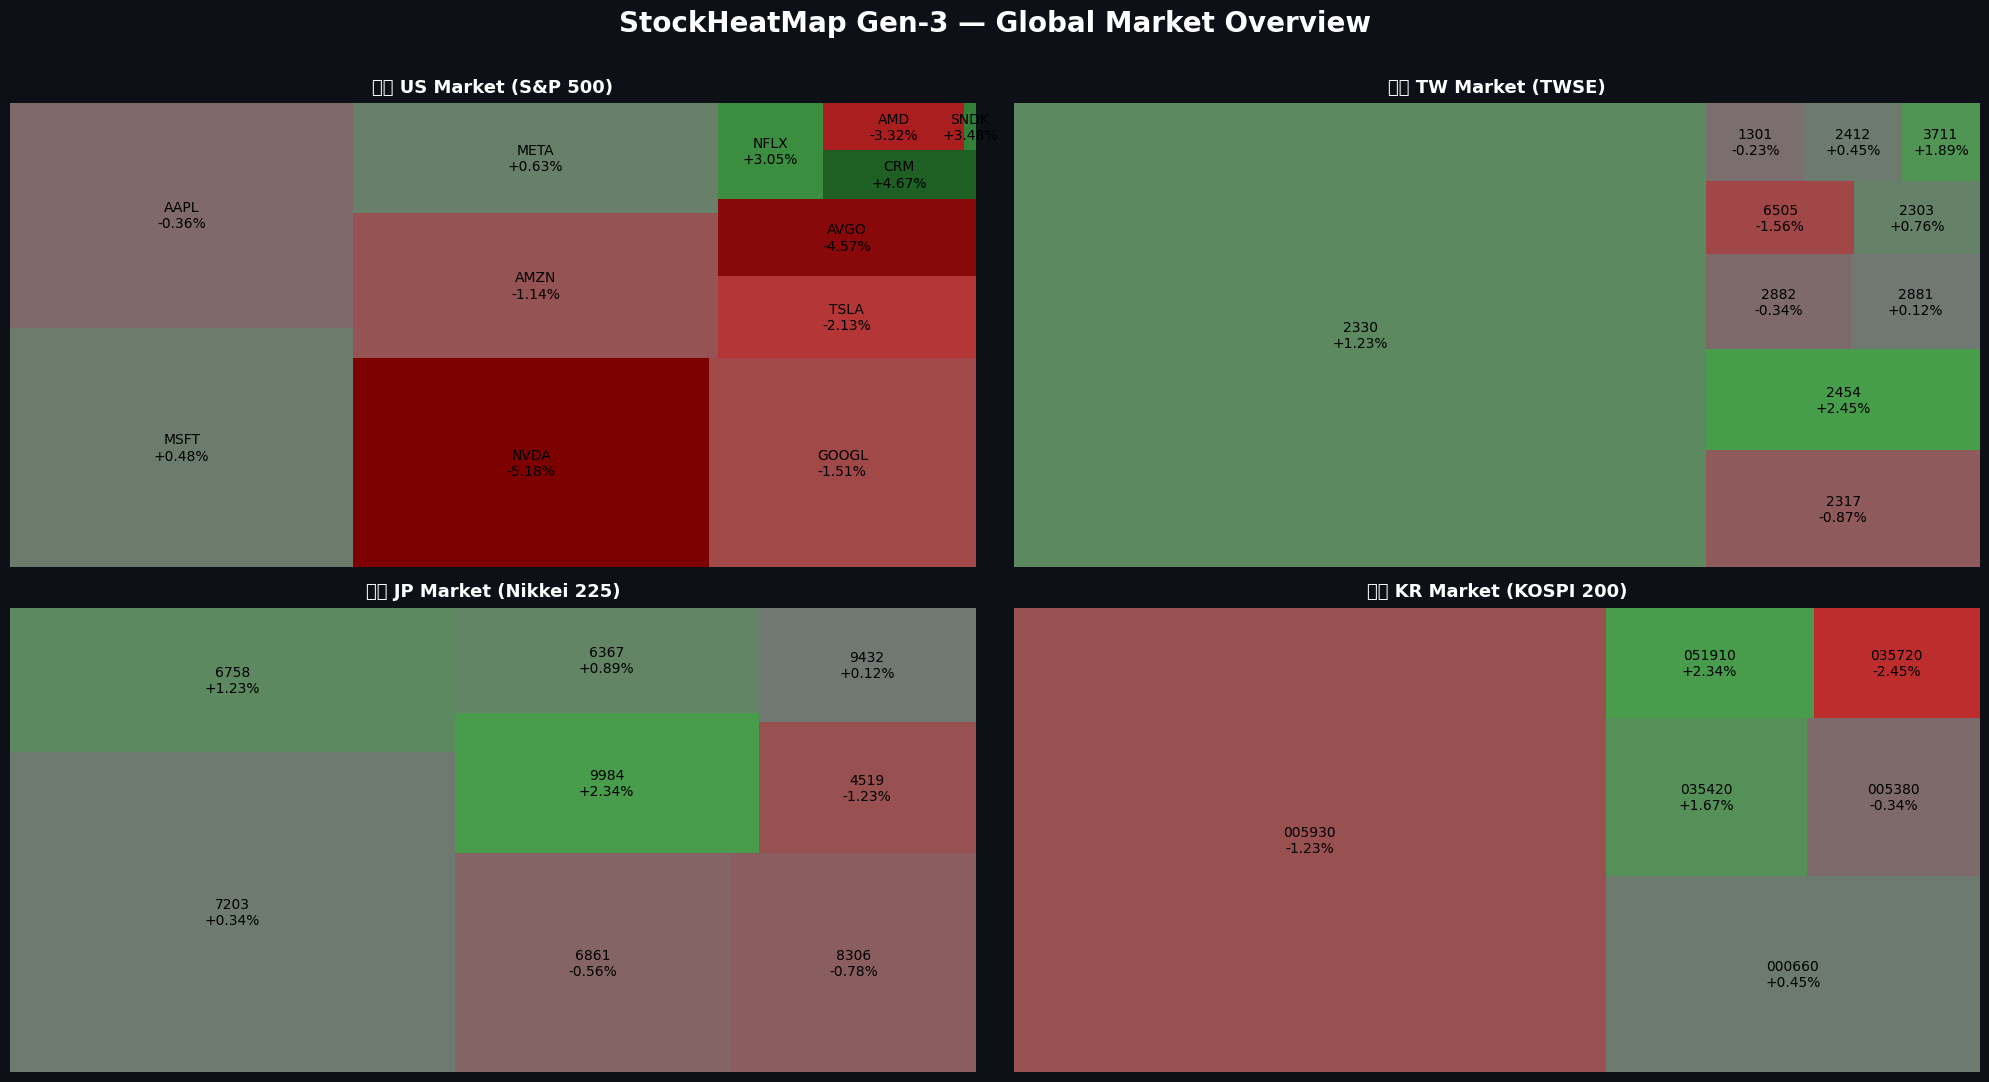


▲ Gen-3 輸出：四地區股市熱力圖（US / TW / JP / KR）並排展示


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Gen-3 四地區熱力圖並排展示
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import squarify

matplotlib.use('Agg')

fig, axes = plt.subplots(2, 2, figsize=(20, 11))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('StockHeatMap Gen-3 — Global Market Overview',
             fontsize=20, weight='bold', color='white', y=0.98)

region_info = [
    ("US", "sample_us.json", "🇺🇸 US Market (S&P 500)"),
    ("TW", "sample_tw.json", "🇹🇼 TW Market (TWSE)"),
    ("JP", "sample_jp.json", "🇯🇵 JP Market (Nikkei 225)"),
    ("KR", "sample_kr.json", "🇰🇷 KR Market (KOSPI 200)"),
]

for ax, (region, filepath, title) in zip(axes.flat, region_info):
    ax.set_facecolor('#161b22')
    stocks = load_from_json(filepath)
    sizes  = [s.market_cap for s in stocks]
    labels = [f"{s.symbol}\n{s.change_pct:+.2f}%" for s in stocks]
    colors = [_pct_to_color(s.change_pct) for s in stocks]

    squarify.plot(
        sizes=sizes, label=labels, color=colors,
        alpha=0.90, ax=ax,
    )
    ax.set_title(title, fontsize=13, color='white', weight='bold', pad=8)
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.97])

output_path_4 = "output/heatmap_ALL_gen3.png"
os.makedirs("output", exist_ok=True)
plt.savefig(output_path_4, dpi=100, bbox_inches='tight', facecolor='#0d1117')
plt.close()

from IPython.display import Image, display
display(Image(filename=output_path_4, width=960))
print("\n▲ Gen-3 輸出：四地區股市熱力圖（US / TW / JP / KR）並排展示")


### 3.5 Gen-3 完整專案結構

```
stockheatmap/
├── cli.py                    # CLI 入口點（Gen-3 完整版）
├── models.py                 # 資料模型（Gen-1 建立，Gen-3 不變）
├── data_loader.py            # 本地檔案載入（Gen-1）
├── cache_manager.py          # 快取管理（Gen-2）
├── treemap_renderer.py       # Treemap 渲染引擎（持續擴展）
├── fetchers/                 # 多地區配接器（Gen-3 新增）
│   ├── __init__.py
│   ├── base.py               # 抽象基底類別（Strategy Pattern）
│   ├── registry.py           # Fetcher 註冊表
│   ├── us_fetcher.py
│   ├── tw_fetcher.py         ← TWSE OpenAPI
│   ├── jp_fetcher.py         ← J-Quants / Yahoo Finance JP
│   └── kr_fetcher.py         ← KRX / Yahoo Finance KR
├── themes/                   # 色彩主題（Gen-3 新增）
│   ├── classic.py
│   ├── monochrome.py
│   └── deuteranopia.py       ← 色盲友善
├── i18n/                     # 多語言（Gen-3 新增）
│   ├── en.yaml
│   ├── zh-TW.yaml
│   ├── ja.yaml
│   └── ko.yaml
├── sample_*.json             # 靜態樣本資料（四地區）
├── stockheatmap.yaml         # 預設設定檔
├── tests/
│   ├── test_gen1.py          # Gen-1 驗收測試（持續回歸）
│   ├── test_gen2.py          # Gen-2 驗收測試
│   └── test_gen3.py          # Gen-3 驗收測試
├── pyproject.toml
├── Dockerfile
└── README.md
```

**模組演進總覽：**

| | Gen-1 | Gen-2 | Gen-3 |
|-|-------|-------|-------|
| 模組數 | 2 | 5 | 10+ |
| CLI 參數 | 0 | 6 | 15+ |
| 測試檔數 | 1 | 2（累積） | 3（累積） |
| 支援地區 | 0（靜態） | US | US/TW/JP/KR/ALL |
| 輸出格式 | PNG | PNG | PNG/SVG/PDF |


---
## Section 4：測試即規格 — 三代累積的 Test Contract

> 核心觀念：測試不是「完成後補的文件」，而是**規格的可執行版本**。  
> 每條測試的名稱都應該能夠直接回答：「這個模組在什麼情況下應該有什麼行為？」

### 4.1 測試命名哲學

```python
# 壞的命名（行為不明確）：
def test_loader():
def test_cache():
def test_cli_works():

# 好的命名（行為即規格）：
def test_load_valid_json_returns_stock_entries():
def test_expired_cache_returns_none():
def test_missing_offline_file_returns_exit_2():
```

### 4.2 三代測試的回歸結構


In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Gen-3 新增測試
# 規格來源：SDD Gen-3 § 3.7 Test Contract
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("=" * 60)
print("Gen-3 Test Contract 執行")
print("=" * 60)

results3 = []

print("\n[TestFetcherRegistry]")

def test_all_regions_registered():
    regions = list_regions()
    assert set(regions) >= {"US", "TW", "JP", "KR"}

results3.append(run_test("all_regions_registered", test_all_regions_registered))

def test_get_valid_fetcher():
    fetcher = get_fetcher("TW")
    assert isinstance(fetcher, BaseFetcher)
    assert fetcher.region_code == "TW"

results3.append(run_test("get_valid_fetcher_returns_correct_type", test_get_valid_fetcher))

def test_get_invalid_region_raises():
    try:
        get_fetcher("XX")
        assert False, "應拋出 ValueError"
    except ValueError as e:
        assert "Unsupported region" in str(e)

results3.append(run_test("get_invalid_region_raises_value_error", test_get_invalid_region_raises))

def test_fetcher_has_required_methods():
    for region in list_regions():
        f = get_fetcher(region)
        assert hasattr(f, 'fetch'),          f"{region} Fetcher 缺少 fetch()"
        assert hasattr(f, 'get_index_name'), f"{region} Fetcher 缺少 get_index_name()"
        assert callable(f.fetch)

results3.append(run_test("fetcher_has_required_methods", test_fetcher_has_required_methods))

print("\n[TestCLI_Gen3]")

def test_all_regions_accepted():
    """所有地區代碼（含 ALL）應被 parser 接受。"""
    parser = build_parser_gen3()
    for region in ['US', 'TW', 'JP', 'KR', 'ALL']:
        args = parser.parse_args(['-r', region])
        assert args.region.upper() == region

results3.append(run_test("all_regions_accepted_by_parser", test_all_regions_accepted))

def test_size_by_parameter():
    parser = build_parser_gen3()
    for metric in ['marketcap', 'volume', 'turnover']:
        args = parser.parse_args(['-r', 'US', '-s', metric])
        assert args.size_by == metric

results3.append(run_test("size_by_accepts_all_metrics", test_size_by_parameter))

def test_format_parameter():
    parser = build_parser_gen3()
    for fmt in ['png', 'svg', 'pdf']:
        args = parser.parse_args(['-r', 'US', '-f', fmt])
        assert args.format == fmt

results3.append(run_test("format_parameter_accepts_png_svg_pdf", test_format_parameter))

def test_theme_parameter():
    parser = build_parser_gen3()
    for theme in ['classic', 'monochrome', 'deuteranopia']:
        args = parser.parse_args(['-r', 'US', '--theme', theme])
        assert args.theme == theme

results3.append(run_test("theme_parameter_accepts_all_themes", test_theme_parameter))

def test_dry_run_does_not_create_file():
    """--dry-run 不應產出圖檔。"""
    output = "/tmp/should_not_exist_dryrun.png"
    if os.path.exists(output):
        os.remove(output)
    main_gen3(['-r', 'US', '--offline', '--dry-run', '-o', output])
    assert not os.path.exists(output), "dry-run 不應產出圖檔"

results3.append(run_test("dry_run_does_not_create_file", test_dry_run_does_not_create_file))

def test_all_region_produces_multiple_outputs():
    """ALL 模式應產出 4 個地區的圖檔。"""
    os.makedirs("output", exist_ok=True)
    exit_code = main_gen3(['-r', 'ALL', '--offline'])
    assert exit_code == 0
    for region in ['US', 'TW', 'JP', 'KR']:
        path = f"output/heatmap_{region}.png"
        assert os.path.exists(path), f"缺少 {path}"

results3.append(run_test("all_region_produces_4_outputs", test_all_region_produces_multiple_outputs))

# ── 完整回歸測試報告 ────────────────────────────────────────
passed3 = sum(results3)
total3  = len(results3)
print(f"\n{'='*60}")
print(f"Gen-3 測試結果：{passed3}/{total3} 通過", "✅" if passed3 == total3 else "⚠️")
print(f"{'='*60}")

total_all = len(results) + len(results2) + len(results3)
passed_all = sum(results) + sum(results2) + sum(results3)
print(f"\n{'='*60}")
print(f"三代累積測試總結：{passed_all}/{total_all} 通過", "✅" if passed_all == total_all else "⚠️")
print(f"  Gen-1: {sum(results)}/{len(results)}")
print(f"  Gen-2: {sum(results2)}/{len(results2)}")
print(f"  Gen-3: {sum(results3)}/{len(results3)}")
print(f"{'='*60}")


Gen-3 Test Contract 執行

[TestFetcherRegistry]
  ✅ PASS │ all_regions_registered
  ✅ PASS │ get_valid_fetcher_returns_correct_type
  ✅ PASS │ get_invalid_region_raises_value_error
  ✅ PASS │ fetcher_has_required_methods

[TestCLI_Gen3]
  ✅ PASS │ all_regions_accepted_by_parser
  ✅ PASS │ size_by_accepts_all_metrics
  ✅ PASS │ format_parameter_accepts_png_svg_pdf
  ✅ PASS │ theme_parameter_accepts_all_themes

[DRY-RUN] Region=US, Stocks=12, Format=png
  輸出路徑（預設）：/tmp/should_not_exist_dryrun.png
  前 5 筆股票：
    MSFT     cap=3.10e+12  chg=+0.48%
    AAPL     cap=2.90e+12  chg=-0.36%
    NVDA     cap=2.80e+12  chg=-5.18%
    GOOGL    cap=2.10e+12  chg=-1.51%
    AMZN     cap=2.00e+12  chg=-1.14%
  ✅ PASS │ dry_run_does_not_create_file
[ALL] 產出所有地區的熱力圖...
  ✓ ./output/heatmap_US.png
  ✓ ./output/heatmap_TW.png
  ✓ ./output/heatmap_JP.png
  ✓ ./output/heatmap_KR.png
  ✅ PASS │ all_region_produces_4_outputs

Gen-3 測試結果：10/10 通過 ✅

三代累積測試總結：27/27 通過 ✅
  Gen-1: 10/10
  Gen-2: 7/7
  Gen-3: 10/10


### 4.3 測試金字塔與 SDD 的對應

```
         ┌─────────┐
         │  E2E    │  ← Demo Checklist（人工操作驗證）
         │  Tests  │     每個 Generation 結束後執行
         ├─────────┤
         │Integration│ ← CLI 整合測試（main() 全流程）
         │  Tests  │     跨模組協作驗證
         ├─────────┤
         │  Unit   │  ← Module Spec 測試（單一模組）
         │  Tests  │     data_loader / renderer / cache
         └─────────┘

SDD 規格對應：
  Unit Tests     → Module Spec 的 約束（Constraints）
  Integration    → Interface Contract 的 輸入/輸出格式
  E2E / Checklist → Scope Declaration 的 「本版本做的事」
```

### 4.4 測試為何要累積不刪除？

| 保留 Gen-N 測試的原因 | 說明 |
|---------------------|------|
| 回歸防護 | 確保 Gen-2/3 的修改不破壞 Gen-1 的核心邏輯 |
| 規格凍結的具象化 | 測試檔本身就是「客戶確認過的規格」的存檔 |
| 重構安全網 | 任何時候想重構，只要測試全通過就代表行為不變 |
| 可審計性 | 任何人在任何時間都能驗證「當時的規格是什麼」 |


---
## Section 5：SDD × AI 協作 — 從規格到 Prompt 工程

> SDD 規格就是你跟 AI 協作時的「對話藍圖」。  
> 規格寫得越精確，AI 產出的程式碼越接近你的預期。

### 5.1 Vibe Coding vs. SDD-Driven AI Collaboration

| | Vibe Coding | SDD + AI |
|-|------------|---------|
| Prompt 風格 | 「幫我寫一個股票資料抓取程式」 | 「請依照以下 Module Spec 實作...」 |
| 輸出可預期性 | 低（AI 自由發揮） | 高（受規格約束） |
| 驗收標準 | 模糊 | 明確（Test Contract） |
| 迭代成本 | 高（大量重寫） | 低（規格 diff 驅動修改） |
| 可維護性 | 低（無文件） | 高（規格即文件） |


In [20]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SDD Prompt 模板示範
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SDD_PROMPT_TEMPLATE = """
你是一位資深 Python 工程師。請嚴格依照以下 Module Spec 實作程式碼：

## Module Spec

**模組名稱**：{module_name}
**檔案路徑**：{file_path}

**職責**：{responsibility}

**公開介面**：
{public_interface}

**約束（必須遵守）**：
{constraints}

**相依**：
{dependencies}

## 實作要求

1. 僅實作規格中定義的公開介面，不新增額外的公開函式
2. 每個函式必須有 docstring，說明參數、回傳值、可能拋出的例外
3. 程式碼必須通過以下驗收測試：

{test_contract}

## 請輸出

1. 完整的 {module_name} 程式碼
2. 簡短說明實作中的關鍵設計決策
"""

# ── 範例：TWFetcher 的 SDD Prompt ────────────────────────────────
print("=" * 70)
print("SDD Prompt 範例：請 AI 實作 TWFetcher")
print("=" * 70)

tw_fetcher_prompt = SDD_PROMPT_TEMPLATE.format(
    module_name="tw_fetcher.py",
    file_path="fetchers/tw_fetcher.py",
    responsibility="""
    從 TWSE OpenAPI 取得台灣上市公司即時交易資料，
    轉換為 StockEntry 列表供 Treemap 渲染使用。""",
    public_interface="""
    class TWFetcher(BaseFetcher):
        region_code   = "TW"
        region_name   = "Taiwan"
        default_top_n = 100

        def fetch(self, top_n: int | None = None) -> list[StockEntry]:
            # 取得台灣上市股票資料

        def get_index_name(self) -> str:
            # 回傳 'TWSE'""",
    constraints="""
    - TWSE API URL: https://openapi.twse.com.tw/v1/exchangeReport/STOCK_DAY_ALL
    - API 呼叫失敗時拋出 ConnectionError（附帶 HTTP status code 或錯誤訊息）
    - 逾時設定：requests timeout=30 秒
    - 回傳資料依 market_cap 降冪排序，取前 top_n 筆
    - 跳過無法解析的個別股票（不影響整體流程）""",
    dependencies="""
    - fetchers.base.BaseFetcher（抽象基底類別）
    - models.StockEntry（資料結構）
    - requests >= 2.28.0""",
    test_contract="""
    def test_tw_fetcher_returns_stock_entries():
        fetcher = TWFetcher()
        stocks = fetcher.fetch(top_n=10)
        assert len(stocks) <= 10
        assert all(isinstance(s, StockEntry) for s in stocks)

    def test_tw_fetcher_sorted_by_market_cap():
        fetcher = TWFetcher()
        stocks = fetcher.fetch()
        for i in range(len(stocks)-1):
            assert stocks[i].market_cap >= stocks[i+1].market_cap

    def test_tw_fetcher_connection_error():
        with patch('requests.get', side_effect=ConnectionError):
            with pytest.raises(ConnectionError):
                TWFetcher().fetch()"""
)

print(tw_fetcher_prompt)


SDD Prompt 範例：請 AI 實作 TWFetcher

你是一位資深 Python 工程師。請嚴格依照以下 Module Spec 實作程式碼：

## Module Spec

**模組名稱**：tw_fetcher.py
**檔案路徑**：fetchers/tw_fetcher.py

**職責**：
    從 TWSE OpenAPI 取得台灣上市公司即時交易資料，
    轉換為 StockEntry 列表供 Treemap 渲染使用。

**公開介面**：

    class TWFetcher(BaseFetcher):
        region_code   = "TW"
        region_name   = "Taiwan"
        default_top_n = 100
        
        def fetch(self, top_n: int | None = None) -> list[StockEntry]:
            # 取得台灣上市股票資料
        
        def get_index_name(self) -> str:
            # 回傳 'TWSE'

**約束（必須遵守）**：

    - TWSE API URL: https://openapi.twse.com.tw/v1/exchangeReport/STOCK_DAY_ALL
    - API 呼叫失敗時拋出 ConnectionError（附帶 HTTP status code 或錯誤訊息）
    - 逾時設定：requests timeout=30 秒
    - 回傳資料依 market_cap 降冪排序，取前 top_n 筆
    - 跳過無法解析的個別股票（不影響整體流程）

**相依**：

    - fetchers.base.BaseFetcher（抽象基底類別）
    - models.StockEntry（資料結構）
    - requests >= 2.28.0

## 實作要求

1. 僅實作規格中定義的公開介面，不新增額外的公開函式
2. 每個函式必須有 docstring，說明參數、回傳值、可能拋出的例外
3. 程式碼必須通過以下驗收測試：

### 5.2 SDD 三層 Prompt 策略

```
Layer 1：架構層 Prompt（每個 Generation 開始前）
  → 給 AI 看完整的 Module Spec 架構圖
  → 確立模組邊界和相依關係
  → 讓 AI 了解「這個模組在整個系統中的位置」

Layer 2：實作層 Prompt（實作單一模組時）
  → 使用上面的 SDD_PROMPT_TEMPLATE
  → 貼上完整的 Interface Contract + Test Contract
  → 讓 AI 有明確的輸入/輸出/約束定義

Layer 3：修復層 Prompt（測試失敗時）
  → 給 AI 失敗的測試輸出 + 現有程式碼
  → 說明「這個測試代表的規格約束是什麼」
  → 要求 AI 修改程式碼直到測試通過（不修改測試）
```

### 5.3 SDD 讓 AI 協作更有效率的三個關鍵

| 關鍵 | 說明 | 做法 |
|------|------|------|
| **精確的介面契約** | AI 不會「猜」函式簽名 | 在 Prompt 中明確定義輸入/輸出型別 |
| **可執行的驗收標準** | 測試是 AI 的自我檢查工具 | 先寫 Test Contract，讓 AI 對著測試實作 |
| **明確的邊界定義** | 避免 AI 過度實作 | Scope Declaration 的「不做什麼」至關重要 |

### 5.4 版本管理建議

```bash
docs/
├── sdd_gen1_v1.0.md        # Gen-1 規格（凍結 ✓）
├── sdd_gen1_v1.0_review.md # Gen-1 客戶檢核記錄
├── sdd_gen2_v1.0.md        # Gen-2 規格（凍結 ✓）
├── sdd_gen2_v1.0_review.md
├── sdd_gen3_v1.0.md        # Gen-3 規格（當前版本）
└── changelog.md            # 跨版本變更總覽

原則：規格文件一旦通過客戶檢核即凍結。
     後續需求用新的 Generation，不覆蓋舊版。
     任何時間點都能回溯「當時的規格是什麼、客戶確認了什麼」。
```


---
## Section 6：課程總結 — SDD 開發節奏回顧

### 6.1 從這個案例學到的開發節奏

```
1. 寫規格  → 不是寫完整個系統，而是「下一步要驗證什麼」
2. 定義測試 → 測試就是規格的可執行版本
3. 最小實作 → 只做到測試通過，不多不少
4. 客戶 Demo → 用 Checklist 結構化檢核，不是隨意展示
5. 凍結規格 → 這一代的承諾不再更改
6. 開新一代 → 基於學習與回饋，撰寫下一代規格
```

### 6.2 三代演進的關鍵決策回顧

| 決策 | 理由 |
|------|------|
| Gen-1 不接 API | 客戶最想先看視覺效果，排除所有技術風險讓核心邏輯先跑通 |
| Gen-2 先接 API 再完整 CLI | API 整合是最大技術風險，獨立一個 Generation 驗證 |
| `StockEntry` 從 Gen-1 定義不變 | 穩定的資料模型讓三代都能無縫協作 |
| 測試永不刪除 | 形成回歸防護網，確保每代修改不破壞舊功能 |
| Strategy Pattern 在 Gen-3 | 等到確定需要多地區時才引入，避免過早抽象 |

### 6.3 延伸學習方向

- **Web 版（PRD 第二版）**：用 FastAPI + React + D3.js 實作互動式 Treemap
- **LLMOps 整合**：加入 AI 自動產生市場評論摘要的功能
- **Agent 工作流**：用 LangGraph 建立自動化的每日市場報告 Pipeline
- **MLOps 排程**：Docker + Airflow 實現企業級自動化部署

---

> **本 Notebook 對應課程**：AIASE 2026 — Generative AI Application Systems and Engineering  
> **SDD 方法論**：Spec-Driven Development — 讓規格驅動開發，讓測試定義完成  


In [21]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 最終輸出驗證 — 確認所有產出物存在
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os

print("=" * 60)
print("最終產出物驗收")
print("=" * 60)

outputs = {
    "Gen-1 US 熱力圖":     "output/heatmap_US_gen1.png",
    "Gen-2 US 熱力圖":     "output/heatmap_US_gen2.png",
    "Gen-3 US 熱力圖":     "output/heatmap_US.png",
    "Gen-3 TW 熱力圖":     "output/heatmap_TW.png",
    "Gen-3 JP 熱力圖":     "output/heatmap_JP.png",
    "Gen-3 KR 熱力圖":     "output/heatmap_KR.png",
    "Gen-3 全球並排圖":     "output/heatmap_ALL_gen3.png",
    "樣本資料 US":          "sample_us.json",
    "樣本資料 TW":          "sample_tw.json",
    "樣本資料 JP":          "sample_jp.json",
    "樣本資料 KR":          "sample_kr.json",
}

all_ok = True
for name, path in outputs.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = f"✅ {size:>8,} bytes" if exists else "❌ 不存在"
    print(f"  {status}  │  {name}  ({path})")
    if not exists:
        all_ok = False

print()
print(f"{'=' * 60}")
print(f"整體狀態：{'✅ 全部完成！' if all_ok else '⚠️  部分輸出缺失，請重新執行相關 Cell'}")
print(f"{'=' * 60}")

total_gen = len(results) + len(results2) + len(results3)
passed_gen = sum(results) + sum(results2) + sum(results3)
print(f"\n三代測試總覽：{passed_gen}/{total_gen} 通過 {'✅' if passed_gen == total_gen else '⚠️'}")


最終產出物驗收
  ✅   44,480 bytes  │  Gen-1 US 熱力圖  (output/heatmap_US_gen1.png)
  ✅   44,480 bytes  │  Gen-2 US 熱力圖  (output/heatmap_US_gen2.png)
  ✅   42,587 bytes  │  Gen-3 US 熱力圖  (output/heatmap_US.png)
  ✅   45,241 bytes  │  Gen-3 TW 熱力圖  (output/heatmap_TW.png)
  ✅   44,354 bytes  │  Gen-3 JP 熱力圖  (output/heatmap_JP.png)
  ✅   40,768 bytes  │  Gen-3 KR 熱力圖  (output/heatmap_KR.png)
  ✅  114,601 bytes  │  Gen-3 全球並排圖  (output/heatmap_ALL_gen3.png)
  ✅    1,841 bytes  │  樣本資料 US  (sample_us.json)
  ✅    1,395 bytes  │  樣本資料 TW  (sample_tw.json)
  ✅    1,127 bytes  │  樣本資料 JP  (sample_jp.json)
  ✅      835 bytes  │  樣本資料 KR  (sample_kr.json)

整體狀態：✅ 全部完成！

三代測試總覽：27/27 通過 ✅
